In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import albumentations as A
from collections import defaultdict
import random

np.random.seed(42)
random.seed(42)

# 1. Configuration parameters for preprocessing

In [2]:
class Config:

    RAW_DATASET_PATH = "/content/drive/MyDrive/Semestre 3/IMAD/Mini projet/DS/gp2"
    PROCESSED_DATASET_PATH = "/content/drive/MyDrive/Semestre 3/IMAD/Mini projet/processed_dataset"

    # Image parameters
    TARGET_SIZE = (224, 224)
    TARGET_FORMAT = 'PNG'

    # Classes
    CLASSES = ['pituitary_tumor', 'no_tumor', 'meningioma_tumor', 'glioma_tumor']

    # Split ratios
    TRAIN_RATIO = 0.7
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15

    # Augmentation parameters
    TARGET_IMAGES_PER_CLASS = 1000

    # Random seed for reproducibility
    RANDOM_STATE = 42

config = Config()

#2. Utility functions

###2.1. Create directory structure for organized dataset

In [ ]:
def create_directory_structure(base_path, subdirs=['train', 'val', 'test']):
    for subdir in subdirs:
        for class_name in config.CLASSES:
            path = os.path.join(base_path, subdir, class_name)
            os.makedirs(path, exist_ok=True)

### 2.2. Load image, convert JPG to RGB, and resize with bicubic interpolation

In [3]:
def load_and_preprocess_image(img_path, target_size=(224, 224)):
    try:
        img = Image.open(img_path)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        img = img.resize(target_size, Image.BICUBIC)
        return np.array(img)
    except Exception as e:
        print(f"Error loading {img_path}: {str(e)}")
        return None

###2.3. Min-Max normalization to [0, 1] for ML models

In [ ]:
def normalize_minmax(img_array):
    img_normalized = img_array.astype(np.float32)
    img_normalized = (img_normalized - img_normalized.min()) / (img_normalized.max() - img_normalized.min() + 1e-8)
    return img_normalized

### 2.4. Keep in [0, 255] range for transfer learning models

In [ ]:
def normalize_0_255(img_array):
    return img_array.astype(np.float32)

#3. Augmentation methods
##3.1. mri-specific augmentation functions
###3.1.1. Simulate MRI bias field inhomogeneity


In [ ]:
def add_bias_field(image, alpha=0.3):

    rows, cols = image.shape[:2]
    x = np.linspace(-1, 1, cols)
    y = np.linspace(-1, 1, rows)
    X, Y = np.meshgrid(x, y)

    # Create smooth bias field
    bias = 1 + alpha * (X**2 + Y**2)
    bias = bias / bias.max()

    # Apply to each channel
    result = image.copy().astype(np.float32)
    for i in range(image.shape[2]):
        result[:, :, i] = np.clip(result[:, :, i] * bias, 0, 255)

    return result.astype(np.uint8)

###3.1.2. Simulate k-space artifacts by removing random lines in frequency domain

In [4]:
def add_kspace_corruption(image, num_lines=5):

    result = image.copy().astype(np.float32)

    for i in range(image.shape[2]):
        # FFT
        f = np.fft.fft2(result[:, :, i])
        fshift = np.fft.fftshift(f)

        # Remove random lines in k-space
        rows = result.shape[0]
        lines_to_remove = np.random.choice(rows, num_lines, replace=False)
        fshift[lines_to_remove, :] = 0

        # Inverse FFT
        f_ishift = np.fft.ifftshift(fshift)
        img_back = np.fft.ifft2(f_ishift)
        result[:, :, i] = np.abs(img_back)

    return np.clip(result, 0, 255).astype(np.uint8)

###3.1.3. Simulate motion artifacts with ghosting effect

In [ ]:
def add_motion_artifact(image, num_ghosts=3, intensity=0.3):
    result = image.copy().astype(np.float32)

    for _ in range(num_ghosts):
        shift_x = np.random.randint(-10, 10)
        shift_y = np.random.randint(-10, 10)

        # Create shifted version
        M = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
        shifted = cv2.warpAffine(result, M, (result.shape[1], result.shape[0]))

        # Blend with original
        result = result * (1 - intensity) + shifted * intensity

    return np.clip(result, 0, 255).astype(np.uint8)

###3.1.4. Simulate spike artifacts in k-space

In [ ]:
def add_spike_artifact(image, num_spikes=3):

    result = image.copy().astype(np.float32)

    for i in range(image.shape[2]):
        # FFT
        f = np.fft.fft2(result[:, :, i])
        fshift = np.fft.fftshift(f)

        # Add random spikes in k-space
        rows, cols = result.shape[:2]
        for _ in range(num_spikes):
            spike_row = np.random.randint(0, rows)
            spike_col = np.random.randint(0, cols)
            fshift[spike_row, spike_col] *= np.random.uniform(5, 15)

        # Inverse FFT
        f_ishift = np.fft.ifftshift(fshift)
        img_back = np.fft.ifft2(f_ishift)
        result[:, :, i] = np.abs(img_back)

    return np.clip(result, 0, 255).astype(np.uint8)

###3.1.5. Add ghosting artifacts typical in MRI

In [ ]:
def add_ghosting_artifact(image, offset=20, alpha=0.4):

    result = image.copy().astype(np.float32)
    ghost = np.roll(result, offset, axis=1)
    result = result * (1 - alpha) + ghost * alpha
    return np.clip(result, 0, 255).astype(np.uint8)

##3.2. Augmentation pipeline
###3.2.1. Define multiple augmentation pipelines with different techniques

#### **1. Geometric Augmentations**
- `geometric_rotation`
- `geometric_shift`
- `geometric_flip_h`
- `geometric_flip_v`
- `geometric_zoom`
- `geometric_crop`
- `geometric_elastic`

#### **2. Intensity-Based Augmentations**
- `intensity_brightness`
- `intensity_contrast`
- `intensity_gamma`
- `intensity_noise`
- `intensity_blur`
- `intensity_brightness_contrast`

#### **3. Channel Augmentations**
- `channel_dropout`
- `channel_shuffle`

#### **4. Cutout-Style Augmentations**
- `cutout`

#### **5. Combined Augmentations**
- `combined_light`
- `combined_medium`
- `combined_heavy`



In [5]:
def get_augmentation_pipelines():

    pipelines = {}

    # 1. Geometric Augmentations
    pipelines['geometric_rotation'] = A.Compose([
        A.Rotate(limit=25, p=1.0, border_mode=cv2.BORDER_CONSTANT)
    ])

    pipelines['geometric_shift'] = A.Compose([
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0, rotate_limit=0, p=1.0)
    ])

    pipelines['geometric_flip_h'] = A.Compose([
        A.HorizontalFlip(p=1.0)
    ])

    pipelines['geometric_flip_v'] = A.Compose([
        A.VerticalFlip(p=1.0)
    ])

    pipelines['geometric_zoom'] = A.Compose([
        A.ShiftScaleRotate(shift_limit=0, scale_limit=0.2, rotate_limit=0, p=1.0)
    ])

    pipelines['geometric_crop'] = A.Compose([
        A.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), p=1.0)
    ])

    pipelines['geometric_elastic'] = A.Compose([
        A.ElasticTransform(alpha=50, sigma=5, p=1.0)
    ])

    # 2. Intensity-Based Augmentations
    pipelines['intensity_brightness'] = A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0, p=1.0)
    ])

    pipelines['intensity_contrast'] = A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0, contrast_limit=0.3, p=1.0)
    ])

    pipelines['intensity_gamma'] = A.Compose([
        A.RandomGamma(gamma_limit=(80, 120), p=1.0)
    ])

    pipelines['intensity_noise'] = A.Compose([
        A.GaussNoise(var_limit=(5.0, 20.0), p=1.0)
    ])

    pipelines['intensity_blur'] = A.Compose([
        A.GaussianBlur(blur_limit=(3, 5), p=1.0)
    ])

    pipelines['intensity_brightness_contrast'] = A.Compose([
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0)
    ])

    # 3. Color/Channel Augmentations
    pipelines['channel_dropout'] = A.Compose([
        A.ChannelDropout(channel_drop_range=(1, 1), p=1.0)
    ])

    pipelines['channel_shuffle'] = A.Compose([
        A.ChannelShuffle(p=1.0)
    ])

    # 4. Cutout-Style Augmentations
    pipelines['cutout'] = A.Compose([
        A.CoarseDropout(
            num_holes_range=(3, 8),
            hole_height_range=(10, 20),
            hole_width_range=(10, 20),
            p=1.0
        )
    ])

    # 5. Combined transformations
    pipelines['combined_light'] = A.Compose([
        A.Rotate(limit=15, p=0.7),
        A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
        A.GaussNoise(var_limit=(5.0, 15.0), p=0.3)
    ])

    pipelines['combined_medium'] = A.Compose([
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=20, p=0.8),
        A.RandomGamma(gamma_limit=(85, 115), p=0.5),
        A.GaussianBlur(blur_limit=(3, 5), p=0.3)
    ])

    pipelines['combined_heavy'] = A.Compose([
        A.ElasticTransform(alpha=30, sigma=5, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.6),
        A.CoarseDropout(
            num_holes_range=(3, 5),
            hole_height_range=(10, 15),
            hole_width_range=(10, 15),
            p=0.3
        )
    ])

    return pipelines

###3.2.2 Apply MRI-specific augmentation

In [ ]:
def apply_mri_augmentation(image, aug_type):

    if aug_type == 'bias_field':
        return add_bias_field(image, alpha=np.random.uniform(0.2, 0.5))
    elif aug_type == 'kspace':
        return add_kspace_corruption(image, num_lines=np.random.randint(3, 8))
    elif aug_type == 'motion':
        return add_motion_artifact(image, num_ghosts=np.random.randint(2, 5),
                                  intensity=np.random.uniform(0.2, 0.4))
    elif aug_type == 'spike':
        return add_spike_artifact(image, num_spikes=np.random.randint(2, 5))
    elif aug_type == 'ghosting':
        return add_ghosting_artifact(image, offset=np.random.randint(15, 30),
                                     alpha=np.random.uniform(0.3, 0.5))
    return image

##3.3. Augmentation engine
Augment images to reach target count using all augmentation methods





In [6]:
def augment_to_target(images, target_count, class_name):

    current_count = len(images)
    needed_augmentations = target_count - current_count

    if needed_augmentations <= 0:
        return images, {}

    print(f"  Augmenting {class_name}: {current_count} -> {target_count} images ({needed_augmentations} augmentations needed)")

    # Initialize pipelines
    pipelines = get_augmentation_pipelines()
    mri_aug_types = ['bias_field', 'kspace', 'motion', 'spike', 'ghosting']

    # Track augmentation statistics
    aug_stats = defaultdict(int)
    augmented_images = []

    # Calculate how many augmentations to apply per technique
    # Prioritize MRI-specific augmentations (40% of augmentations)
    mri_aug_count = int(needed_augmentations * 0.4)
    other_aug_count = needed_augmentations - mri_aug_count

    # Apply MRI-specific augmentations
    print(f"    Applying MRI-specific augmentations...")
    augmented_images_with_names = []  # Store tuples of (image, aug_name)

    for i in tqdm(range(mri_aug_count), desc="    MRI augmentations"):
        # Select random original image
        original_img = random.choice(images)

        # Select random MRI augmentation type
        aug_type = random.choice(mri_aug_types)
        aug_stats[f'mri_{aug_type}'] += 1

        # Apply augmentation
        augmented = apply_mri_augmentation(original_img.copy(), aug_type)
        augmented_images_with_names.append((augmented, f'mri_{aug_type}'))

    # Apply other augmentations
    print(f"    Applying geometric, intensity, and other augmentations...")
    pipeline_names = list(pipelines.keys())

    for i in tqdm(range(other_aug_count), desc="    Other augmentations"):
        # Select random original image
        original_img = random.choice(images)

        # Select random pipeline
        pipeline_name = random.choice(pipeline_names)
        aug_stats[pipeline_name] += 1

        # Apply augmentation
        augmented = pipelines[pipeline_name](image=original_img)['image']
        augmented_images_with_names.append((augmented, pipeline_name))

    # Combine original and augmented images
    # Original images don't have augmentation names
    all_images_with_names = [(img, 'original') for img in images] + augmented_images_with_names

    return all_images_with_names, dict(aug_stats)

#4. main preprocessing pipeline


In [7]:
def preprocess_and_augment_dataset(raw_path, output_path_ml, output_path_dl):

    create_directory_structure(output_path_ml)
    create_directory_structure(output_path_dl)

    # Global statistics
    global_stats = {
        'preprocessing': {
            'successful': 0,
            'failed': 0
        },
        'augmentation': {},
        'final_counts': {}
    }

    # Process each class
    for class_name in config.CLASSES:
        print(f"\n{'-'*70}")
        print(f"PROCESSING CLASS: {class_name.upper()}")
        print(f"{'-'*70}")

        class_path = os.path.join(raw_path, class_name)

        if not os.path.exists(class_path):
            print(f"Warning: {class_path} does not exist. Skipping...")
            continue

        # Load all images for this class
        print(f"Loading original images...")
        image_files = [f for f in os.listdir(class_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        loaded_images = []
        for img_file in tqdm(image_files, desc=f"Loading {class_name}"):
            img_path = os.path.join(class_path, img_file)
            img = load_and_preprocess_image(img_path, config.TARGET_SIZE)
            if img is not None:
                loaded_images.append(img)
                global_stats['preprocessing']['successful'] += 1
            else:
                global_stats['preprocessing']['failed'] += 1

        print(f"Successfully loaded: {len(loaded_images)} images")

        # Augment to target count
        augmented_images_with_names, aug_stats = augment_to_target(
            loaded_images,
            config.TARGET_IMAGES_PER_CLASS,
            class_name
        )

        global_stats['augmentation'][class_name] = aug_stats
        global_stats['final_counts'][class_name] = len(augmented_images_with_names)

        # Split dataset
        print(f"  Splitting dataset...")
        train_data, temp_data = train_test_split(
            augmented_images_with_names,
            test_size=(config.VAL_RATIO + config.TEST_RATIO),
            random_state=config.RANDOM_STATE
        )
        val_data, test_data = train_test_split(
            temp_data,
            test_size=config.TEST_RATIO/(config.VAL_RATIO + config.TEST_RATIO),
            random_state=config.RANDOM_STATE
        )

        splits = {
            'train': train_data,
            'val': val_data,
            'test': test_data
        }

        print(f"  Split sizes - Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

        # Save images
        print(f"  Saving processed images...")
        for split_name, data_list in splits.items():
            for idx, (img, aug_name) in enumerate(tqdm(data_list, desc=f"  Saving {split_name}")):
                # Create filename with augmentation technique
                if aug_name == 'original':
                    filename_base = f"{class_name}_{split_name}_{idx:04d}"
                else:
                    filename_base = f"{class_name}_{split_name}_{idx:04d}_{aug_name}"

                # Save for ML (normalized [0,1])
                img_ml = normalize_minmax(img)
                ml_path = os.path.join(output_path_ml, split_name, class_name,
                                      f"{filename_base}.npy")
                np.save(ml_path, img_ml)

                # Save for DL ([0,255])
                img_dl = normalize_0_255(img)
                dl_path = os.path.join(output_path_dl, split_name, class_name,
                                      f"{filename_base}.png")
                Image.fromarray(img_dl.astype(np.uint8)).save(dl_path)

    return global_stats

#5. visualization and reporting

##5.1. Print detailed augmentation statistics

In [ ]:
def print_augmentation_report(stats):

    print("\n" + "*"*70)
    print("Augmentation statistics report")
    print("*"*70)

    for class_name, aug_stats in stats['augmentation'].items():
        print(f"\n{class_name.upper()}:")
        print(f"  Final count: {stats['final_counts'][class_name]} images")

        if aug_stats:
            print(f"  Augmentation techniques used:")

            # Group by category
            mri_augs = {k: v for k, v in aug_stats.items() if k.startswith('mri_')}
            geometric_augs = {k: v for k, v in aug_stats.items() if k.startswith('geometric_')}
            intensity_augs = {k: v for k, v in aug_stats.items() if k.startswith('intensity_')}
            channel_augs = {k: v for k, v in aug_stats.items() if k.startswith('channel_')}
            other_augs = {k: v for k, v in aug_stats.items()
                         if not any(k.startswith(p) for p in ['mri_', 'geometric_', 'intensity_', 'channel_'])}

            if mri_augs:
                print(f"\n    MRI-Specific Augmentations ({sum(mri_augs.values())} total):")
                for method, count in sorted(mri_augs.items(), key=lambda x: x[1], reverse=True):
                    print(f"      • {method}: {count}")

            if geometric_augs:
                print(f"\n    Geometric Augmentations ({sum(geometric_augs.values())} total):")
                for method, count in sorted(geometric_augs.items(), key=lambda x: x[1], reverse=True):
                    print(f"      • {method}: {count}")

            if intensity_augs:
                print(f"\n    Intensity Augmentations ({sum(intensity_augs.values())} total):")
                for method, count in sorted(intensity_augs.items(), key=lambda x: x[1], reverse=True):
                    print(f"      • {method}: {count}")

            if channel_augs:
                print(f"\n    Channel Augmentations ({sum(channel_augs.values())} total):")
                for method, count in sorted(channel_augs.items(), key=lambda x: x[1], reverse=True):
                    print(f"      • {method}: {count}")

            if other_augs:
                print(f"\n    Other Augmentations ({sum(other_augs.values())} total):")
                for method, count in sorted(other_augs.items(), key=lambda x: x[1], reverse=True):
                    print(f"      • {method}: {count}")

##5.2. Visualize augmented samples from each class

In [8]:
def visualize_augmentation_samples(dl_dataset_path, num_samples=5):

    fig, axes = plt.subplots(len(config.CLASSES), num_samples,
                            figsize=(15, len(config.CLASSES) * 3))

    for i, class_name in enumerate(config.CLASSES):
        class_path = os.path.join(dl_dataset_path, 'train', class_name)
        images = [f for f in os.listdir(class_path) if f.endswith('.png')]
        sample_images = random.sample(images, min(num_samples, len(images)))

        for j, img_file in enumerate(sample_images):
            img = Image.open(os.path.join(class_path, img_file))

            if len(config.CLASSES) == 1:
                axes[j].imshow(img)
                axes[j].axis('off')
            else:
                axes[i, j].imshow(img)
                axes[i, j].axis('off')
                if j == 0:
                    axes[i, j].set_ylabel(class_name.replace('_', ' ').title(),
                                         fontsize=12, fontweight='bold')

    plt.suptitle('Augmented Training Samples', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(config.PROCESSED_DATASET_PATH, 'augmentation_samples.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

##5.3. Plot final class distribution

In [ ]:
def plot_class_distribution(stats):

    classes = list(stats['final_counts'].keys())
    counts = list(stats['final_counts'].values())

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(classes, counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])

    ax.set_xlabel('Class', fontweight='bold', fontsize=12)
    ax.set_ylabel('Number of Images', fontweight='bold', fontsize=12)
    ax.set_title('Final Dataset Distribution (After Augmentation)',
                fontweight='bold', fontsize=14)
    ax.set_xticklabels([c.replace('_', '\n') for c in classes], rotation=0)
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(height)}',
               ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig(os.path.join(config.PROCESSED_DATASET_PATH, 'final_distribution.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

#6. Main execution


## 6.1. Define output paths

In [9]:
output_path_ml = os.path.join(config.PROCESSED_DATASET_PATH, 'ml_dataset')
output_path_dl = os.path.join(config.PROCESSED_DATASET_PATH, 'dl_dataset')

##6.2. Run preprocessing and augmentation

In [10]:
stats = preprocess_and_augment_dataset(raw_path=config.RAW_DATASET_PATH,
                                       output_path_ml=output_path_ml,
                                       output_path_dl=output_path_dl
                                       )


----------------------------------------------------------------------
PROCESSING CLASS: PITUITARY_TUMOR
----------------------------------------------------------------------
Loading original images...


Loading pituitary_tumor: 100%|██████████| 812/812 [00:20<00:00, 40.40it/s] 
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipython-input-4094990436.py:49: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=1.0)
/tmp/ipython-input-4094990436.py:83: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 15.0), p=0.3)


Successfully loaded: 812 images
  Augmenting pituitary_tumor: 812 -> 1000 images (188 augmentations needed)
    Applying MRI-specific augmentations...


    MRI augmentations: 100%|██████████| 75/75 [00:00<00:00, 193.09it/s]


    Applying geometric, intensity, and other augmentations...


...

    MRI augmentations: 100%|██████████| 74/74 [00:00<00:00, 250.43it/s]


    Applying geometric, intensity, and other augmentations...


    Other augmentations: 100%|██████████| 112/112 [00:00<00:00, 1001.00it/s]


  Splitting dataset...
  Split sizes - Train: 700, Val: 150, Test: 150
  Saving processed images...


  Saving test: 100%|██████████| 150/150 [00:06<00:00, 24.25it/s]


##6.3. Print results

In [11]:
print(f"\n Successfully processed: {stats['preprocessing']['successful']} images")
print(f" Failed: {stats['preprocessing']['failed']} images")
print(f"\n Final dataset contains {sum(stats['final_counts'].values())} images total")


 Successfully processed: 2417 images
 Failed: 0 images

 Final dataset contains 4000 images total


##6.4. Print detailed augmentation report

In [12]:
print_augmentation_report(stats)


**********************************************************************
Augmentation statistics report
**********************************************************************

PITUITARY_TUMOR:
  Final count: 1000 images
  Augmentation techniques used:

    MRI-Specific Augmentations (75 total):
      • mri_bias_field: 18
      • mri_motion: 17
      • mri_kspace: 14
      • mri_ghosting: 14
      • mri_spike: 12

    Geometric Augmentations (38 total):
      • geometric_flip_h: 10
      • geometric_elastic: 7
      • geometric_flip_v: 6
      • geometric_crop: 5
      • geometric_shift: 5
      • geometric_rotation: 3
      • geometric_zoom: 2

    Intensity Augmentations (38 total):
      • intensity_brightness: 11
      • intensity_contrast: 8
      • intensity_noise: 8
      • intensity_gamma: 5
      • intensity_blur: 4
      • intensity_brightness_contrast: 2

    Channel Augmentations (11 total):
      • channel_dropout: 6
      • channel_shuffle: 5

    Other Augmentations (26 to


 Generating visualizations...


/tmp/ipython-input-1915949166.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c.replace('_', '\n') for c in classes], rotation=0)


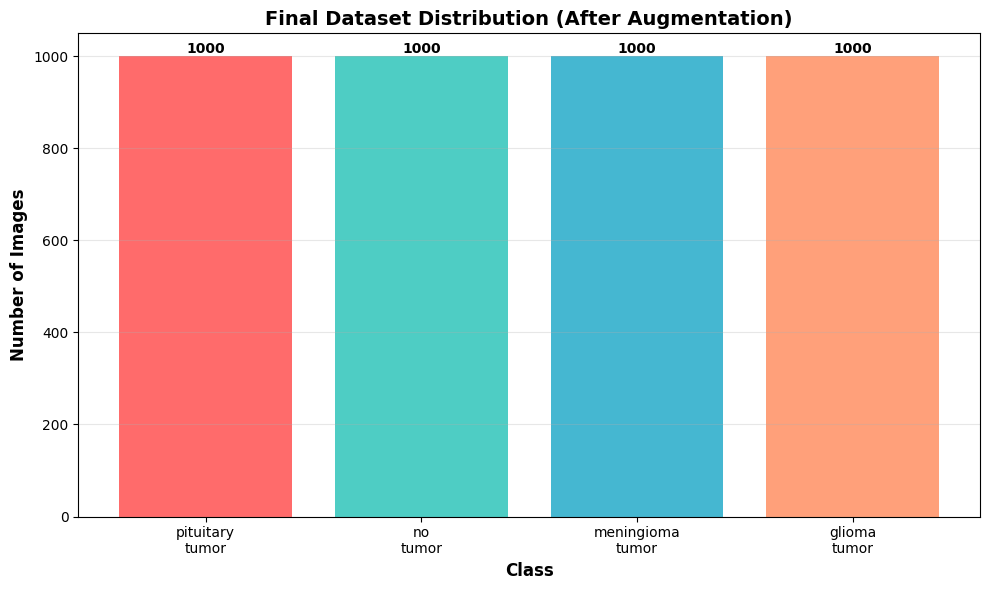

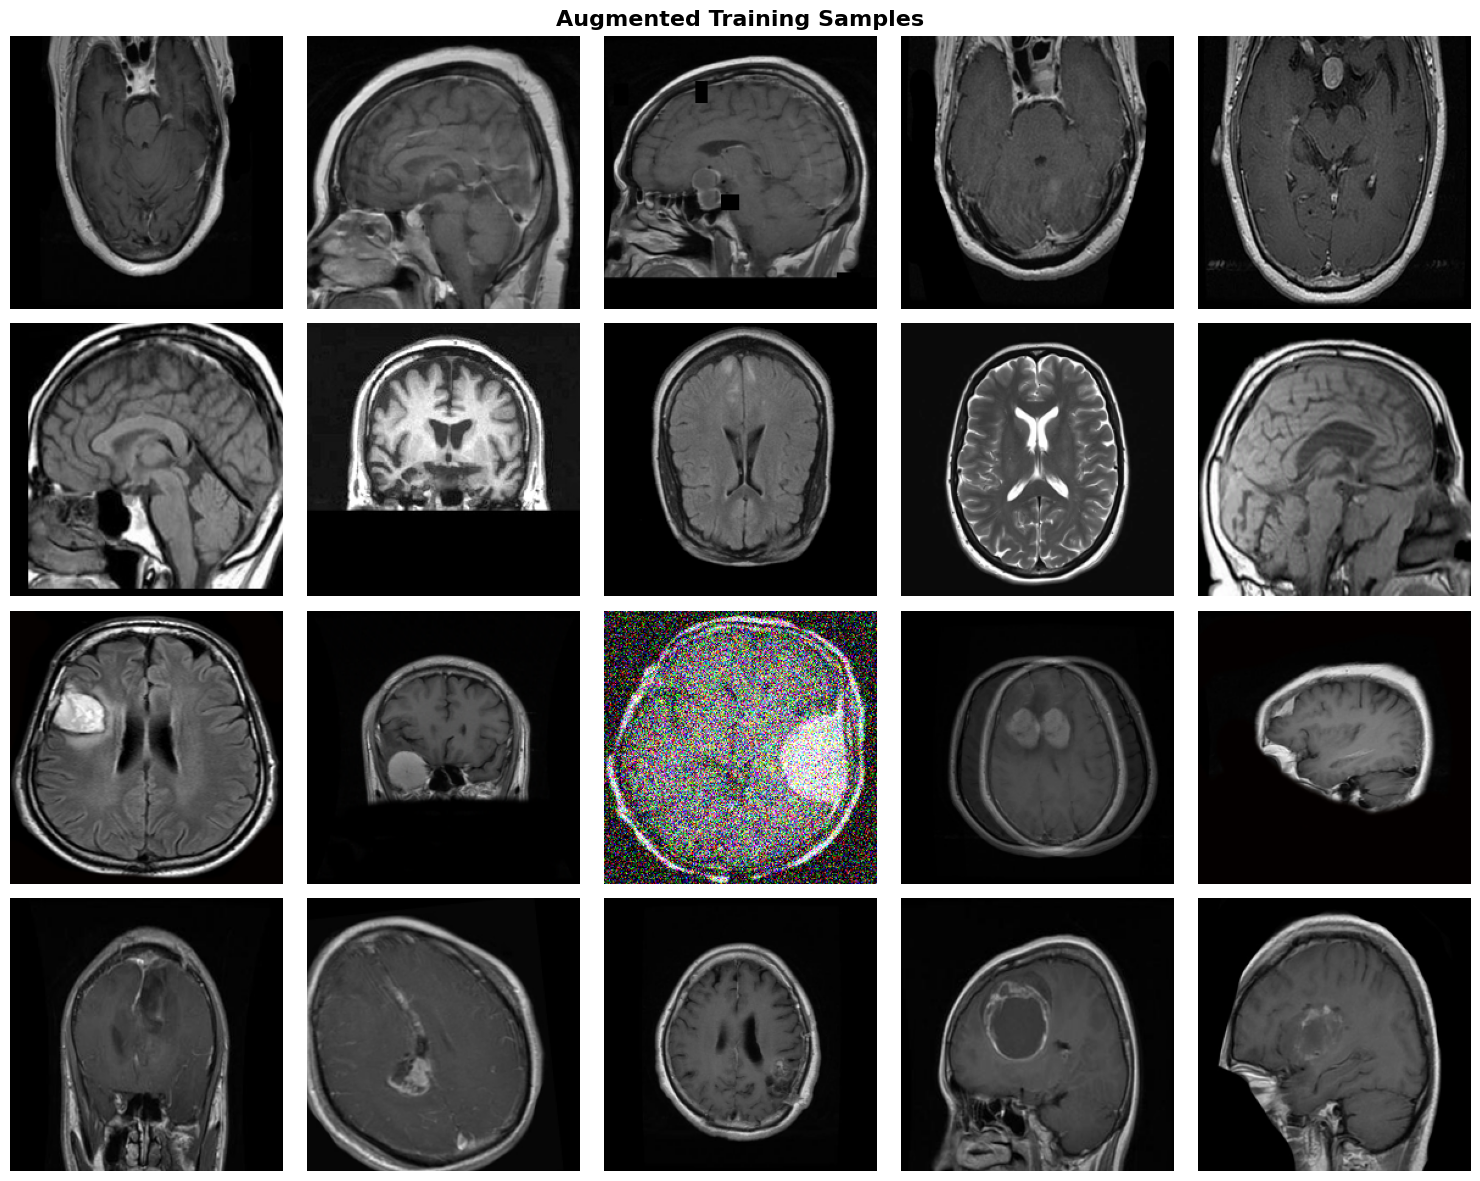


 ML Dataset: /content/drive/MyDrive/Semestre 3/IMAD/Mini projet/processed_dataset/ml_dataset
 DL Dataset: /content/drive/MyDrive/Semestre 3/IMAD/Mini projet/processed_dataset/dl_dataset


In [18]:
print("\n Generating visualizations...")
plot_class_distribution(stats)
visualize_augmentation_samples(output_path_dl, num_samples=5)
print(f"\n ML Dataset: {output_path_ml}")
print(f" DL Dataset: {output_path_dl}")